# Measuring the Carbon Footprint of Machine Learning with CodeCarbon

**A hands-on learning guide, using the BOA Constrictor neural compressor as its example workload.**

Training a machine learning model consumes electricity, and generating that electricity
usually releases greenhouse gases. This notebook teaches you how to *measure* that cost rather than
guess at it, using the open-source Python package **CodeCarbon** [1].

The running example is
the **BOA Constrictor** [4, 5] workload, a neural network that losslessly compresses
particle-physics data. You do **not** need to understand neural compression to follow along.

> **Before you start (Google Colab).** Go to **Runtime -> Change runtime type -> T4 GPU**, then
> **Runtime -> Run all**. The notebook also runs on a CPU-only runtime: it automatically shrinks the
> demo and tells you it has done so.
>
> **Reference machine.** Wherever this notebook quotes absolute energy numbers from our own
> experiments, they were measured on a **single Google Colab Tesla T4 GPU instance** on the
> **UK electricity grid**. They are a concrete illustration, *not* universal constants — your own
> numbers will differ with hardware, region and workload.

# Table of Contents

*   [Overview](#overview)
*   [Target Audience](#target-audience)
*   [Software Requirements](#software-requirements)
*   [Installation](#installation)
*   [Data Description](#data-description)
*   [What is BOA Constrictor?](#about-boa)
*   [Carbon Emissions Estimation Framework](#estimation-framework)
*   [Measuring Power Usage](#measuring-power)
*   [Hardware Power Consumption](#hardware-power)
*   [Hands-on: Measuring CodeCarbon on BOA](#hands-on)
*   [Results & Discussion](#results-and-discussion)
*   [Where to Go Next](#where-next)
*   [References](#references)

<a name="overview"></a>

# Overview

Reporting the carbon footprint of a machine learning experiment is becoming a normal part of
publishing one, in much the same way that reporting hardware and runtime already is [2]. Doing that requires understanding what is actually being measured, what is being *estimated*, and how
large the uncertainty is.

Specifically, you will learn how to:

- **Distinguish** the two kinds of emissions attributable to a computation: *operational* emissions
  from the electricity used while it runs, and *embodied* emissions from manufacturing the hardware
  it runs on.
- **Write down** the estimation formula, $C_{operational} = E \times I$, and understand which of its
  terms are measured directly and which are looked up in a table.
- **Explain** where the energy actually goes inside a machine — GPU, CPU, RAM — and why *total
  energy*, not peak power, is the quantity that determines emissions.
- **Instrument** an arbitrary block of Python with CodeCarbon's `OfflineEmissionsTracker`, using a
  small reusable `track()` context manager.
- **Interpret** the resulting numbers: what `energy_consumed` (kWh) and `emissions`
  (kg CO<sub>2</sub>eq) mean, how they relate, and how much the answer moves when the same job runs
  on a different electricity grid.
- **Recognise** the limits of the measurement — what CodeCarbon samples, what it models from
  look-up tables, and what it leaves out entirely.

A note on units before we begin: **kg CO<sub>2</sub>eq** means *kilograms of carbon dioxide
equivalent*. Different greenhouse gases trap different amounts of heat, so carbon accounting
converts them all into the mass of CO<sub>2</sub> that would have the same warming effect. It is the
standard unit for reporting a footprint as a single comparable number.

<a name="target-audience"></a>

# Target Audience

This guide is written for students and self-taught learners who can read and run Python. If
you have used a Jupyter notebook and know roughly what a GPU is, you have the prerequisites.

<a name="software-requirements"></a>

# Software Requirements

This notebook targets **Python 3.10–3.12** and was developed against the Google Colab image
(Python 3.12, CUDA 12.8). The packages it needs fall into three groups: the thing being measured,
the thing doing the measuring, and the usual data-handling tools.

| Package | Version used here | Why it is needed |
|---|---|---|
| `codecarbon` | >= 3.2, < 4 | **The subject of this notebook**: samples hardware power draw and converts energy to CO<sub>2</sub>eq. |
| `torch` | whatever the runtime ships (>= 2.6) | Runs the neural network being measured. **Not installed by this notebook** — we use Colab's own build, which already matches its GPU driver. |
| `mambapy` | 1.2.0 | Pure-PyTorch implementation of the Mamba layer — BOA's portable backbone. Runs on GPU *or* CPU. |
| `mamba-ssm`, `causal-conv1d` | 2.3.2.post1, 1.7.0 — **optional** | Fused CUDA kernels for that same layer. Several times faster, but only installable when a pre-built wheel matches the runtime's exact Python / PyTorch / CUDA combination. |
| `minGRU-pytorch` | latest | Imported at the top of BOA's `model.py`, so it must be present whichever backbone you choose. |
| `constriction` | 0.4.1 | BOA's CPU entropy coder [9] — the half of the compressor that turns predicted probabilities into bits. |
| `pybind11` | latest | Used to build BOA's custom CUDA range coder, the GPU version of that same step. |
| `pandas` | >= 2.0 | Reads CodeCarbon's output CSV into a table. |
| `matplotlib` | >= 3.0 | Plots the energy breakdown. |
| `numpy`, `tqdm` | latest | Array handling and progress bars (both preinstalled on Colab). |

**Is a GPU required?** No — but it is strongly recommended.

* **With a GPU (recommended):** CodeCarbon reads the NVIDIA GPU's power draw directly from the
  driver, so the dominant energy term is a genuine measurement rather than an estimate. The hands-on
  demo takes a couple of minutes on a Colab T4.
* **CPU only:** everything still runs. BOA falls back to the pure-PyTorch `mambapy` backbone, the
  notebook automatically shrinks the demo (less data, one epoch) and prints a message saying so.
  CPU power is *modelled* from a look-up table rather than measured, which is itself a useful
  lesson — see [Measuring Power Usage](#measuring-power).

To enable a GPU in Colab: **Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU -> Save.**

<a name="installation"></a>

# Installation

The cell below installs what the notebook needs, splitting packages into **required** and
**optional**.

* **Required** — CodeCarbon itself, `mambapy` (BOA's portable pure-PyTorch backbone),
  `minGRU-pytorch` (imported at the top of BOA's `model.py`, so it must be present whatever backbone
  you use), `constriction` [9] and `pybind11` for the entropy coder, plus `pandas` and
  `matplotlib`. If one of these fails the cell raises immediately, because nothing downstream could
  work anyway.
* **Optional** — the *fused Mamba CUDA kernels*, `causal-conv1d` and `mamba-ssm`. They make training
  several times faster, but they are compiled binaries that must match your exact Python version,
  PyTorch version and CUDA version. If no matching wheel exists the cell says so and carries on;
  BOA then uses the pure-PyTorch backbone, which still trains on the GPU.

Note:

* **We do not install PyTorch.** Colab already ships a build matched to its own GPU driver, and
  replacing it is a reliable way to break a working runtime. Instead we *read* the version that is
  there and construct the kernel wheel filenames from it, rather than hard-coding filenames that go
  stale the moment Colab upgrades its Python. (This notebook originally hard-coded `cp312` wheels
  and broke as soon as Colab moved to Python 3.13 — hence the runtime detection below.)
* **Version pins are checked against the runtime.** `constriction==0.4.1` is
  pinned because BOA's codec is written against that API, and it does publish a wheel for current
  Python versions. A pin that has no matching wheel is exactly the failure described above.

Outside Colab the cell touches nothing and simply prints the command for you to run yourself.

In [1]:
import subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

def pip(*args, optional=False):
    '''Install packages. A failed *optional* install is reported; a required one stops the run.'''
    print("pip install", *args)
    done = subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args],
                          capture_output=optional, text=True)
    if done.returncode and not optional:
        raise RuntimeError(f"Required install failed: {' '.join(args)}")
    return done.returncode == 0

if IN_COLAB:
    # --- required: the tracker, BOA's portable backbone, plotting ------------------------------
    # minGRU-pytorch is imported at the top of the repo's model.py, so it is required
    # even when the backbone is Mamba.
    pip("codecarbon>=3.2,<4", "mambapy==1.2.0", "minGRU-pytorch", "constriction==0.4.1",
        "pybind11", "pandas>=2.0", "matplotlib>=3.0", "tqdm")

    # --- optional: fused Mamba CUDA kernels, if a wheel matches THIS runtime --------------------
    import torch
    py = f"cp{sys.version_info.major}{sys.version_info.minor}"        # e.g. cp313
    tv = ".".join(torch.__version__.split("+")[0].split(".")[:2])     # e.g. 2.8
    cu = (torch.version.cuda or "").split(".")[0]                     # "12" or "13"
    fused = False

    if torch.cuda.is_available() and cu in ("12", "13"):
        CC = "https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.7.0/"
        MS = "https://github.com/state-spaces/mamba/releases/download/v2.3.2.post1/"
        for abi in ("TRUE", "FALSE"):                                 # ABI varies by torch build
            tag = f"cu{cu}torch{tv}cxx11abi{abi}-{py}-{py}-linux_x86_64.whl"
            if (pip(f"{CC}causal_conv1d-1.7.0+{tag}", optional=True)
                    and pip(f"{MS}mamba_ssm-2.3.2.post1+{tag}", "--no-deps", optional=True)):
                fused = True
                break
        print(f"[kernels] fused mamba_ssm ready for {py} / torch {tv} / cu{cu}" if fused else
              f"[kernels] no fused wheel for {py} / torch {tv} / cu{cu} - "
              "falling back to pure-PyTorch mambapy (still on the GPU, just slower)")
    else:
        print("[kernels] no CUDA GPU - using the pure-PyTorch mambapy backbone")
else:
    print("Local run. Install once with:\n"
          "  pip install codecarbon mambapy==1.2.0 minGRU-pytorch constriction==0.4.1 \\\n"
          "              pybind11 pandas matplotlib tqdm\n"
          "  plus a PyTorch build for your machine: https://pytorch.org/get-started/locally/")

pip install codecarbon>=3.2,<4 mambapy==1.2.0 minGRU-pytorch constriction==0.4.1 pybind11 pandas>=2.0 matplotlib>=3.0 tqdm
pip install https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.7.0/causal_conv1d-1.7.0+cu12torch2.11cxx11abiTRUE-cp313-cp313-linux_x86_64.whl
pip install https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.7.0/causal_conv1d-1.7.0+cu12torch2.11cxx11abiFALSE-cp313-cp313-linux_x86_64.whl
[kernels] no fused wheel for cp313 / torch 2.11 / cu12 - falling back to pure-PyTorch mambapy (still on the GPU, just slower)


Next, a quick look at what hardware you actually have. This matters more than it might seem: the
*quality* of a CodeCarbon measurement depends on the hardware, because different components are
measured in different ways (the next sections explain why). Run this to confirm whether you are on a
GPU runtime and, if so, which GPU — and make a note of its name, because an energy number is only
meaningful alongside the machine that produced it.

In [2]:
import torch

print(f"torch {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU:   {torch.cuda.get_device_name(0)}")
    print(f"VRAM:  {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU:   none detected - this notebook will run a smaller CPU demo.")
    print("       On Colab: Runtime -> Change runtime type -> T4 GPU.")

torch 2.11.0+cu128
GPU:   Tesla T4
VRAM:  15.6 GB


<a name="data-description"></a>

# Data Description

The workload we measure compresses **`CMS_DATA_float32.bin`**, a dataset distributed with the BOA
Constrictor repository [4] and derived from open data released by the CMS experiment at the CERN
Large Hadron Collider [8].

**What is in the file.** It is a *flat binary array* of IEEE-754 `float32` values — no header, no
delimiters, just 4 bytes per number, one after another. Reshaped, it is **N rows x 24 columns**, and
each row describes one **reconstructed jet**: the spray of particles recorded by the detector when a
quark or gluon is produced in a proton-proton collision. The full file is **49.92 MB**, which is
49,920,000 bytes = 520,000 jets x 24 features x 4 bytes.

The 24 columns per jet are, in order:

| # | Feature | # | Feature |
|---|---|---|---|
| 1 | `pt` — transverse momentum (GeV) | 13 | charged hadron multiplicity (count) |
| 2 | `eta` — pseudorapidity | 14 | neutral hadron multiplicity |
| 3 | `phi` — azimuthal angle (rad) | 15 | photon multiplicity |
| 4 | `mass` (GeV) | 16 | electron multiplicity |
| 5 | `jet_area` | 17 | muon multiplicity |
| 6 | charged hadron energy (GeV) | 18 | HF hadron multiplicity |
| 7 | neutral hadron energy (GeV) | 19 | HF EM multiplicity |
| 8 | photon energy (GeV) | 20 | charged EM energy (GeV) |
| 9 | electron energy (GeV) | 21 | charged muon energy (GeV) |
| 10 | muon energy (GeV) | 22 | neutral EM energy (GeV) |
| 11 | HF hadron energy (GeV) | 23 | charged multiplicity (count) |
| 12 | HF EM energy (GeV) | 24 | neutral multiplicity (count) |

("HF" is the detector's *forward hadronic calorimeter*; "multiplicity" is simply a count of
particles of that type in the jet.)

**Why lossless compression, and why it matters here.** The LHC produces data far faster than it can
be stored, and archives of this kind run to hundreds of petabytes. Storing less would be enormously
valuable — but a *lossy* compressor, of the kind used for photographs or audio, is not acceptable:
it would perturb the very numbers a physics analysis is trying to measure, and no one could later
prove that a discovery was not an artefact of the compression. **Lossless** compression guarantees
that decompressing returns the original bytes *exactly*, so downstream analysis is unaffected. The
question BOA asks is whether a neural network can push the lossless compression ratio high enough to
be worth the electricity it costs to run — which is precisely the kind of question this notebook
teaches you to answer with numbers.

For this notebook we only ever use a **10 MB slice** taken from the front of the file. That is
enough to produce a realistic measurement in a couple of minutes.

<a name="about-boa"></a>

# What is BOA Constrictor?

**BOA Constrictor** [4, 5] is a *lossless* neural compressor for scientific data. It works in two
stages: a small **Mamba** network [6] — a state-space sequence model, an efficient alternative to a
Transformer — reads the bytes of a file one at a time and predicts a probability for each of the 256
possible values of the *next* byte; a **range coder** then turns those probabilities into a
bitstream whose length is close to the information-theoretic ideal of
$-\sum \log_2 p(\text{byte})$ bits. Better predictions mean fewer bits, and because decompression
replays exactly the same predictions in the same order, the round trip is bit-for-bit exact.

For our purposes, what makes BOA a good **example workload** is not its architecture but its shape.
It is small enough to train in minutes on a free Colab GPU, yet it is a real research code doing
real GPU work — so the measurement exercises the same machinery you would use on a serious job. It
also has a genuinely interesting energy question attached: compression *saves* the emissions of
storing data, but *costs* the emissions of training and running the network, and only measurement
can tell you which wins.

This notebook treats BOA as a black box that consumes electricity; the
full pipeline is documented in the companion notebooks listed under
[Where to Go Next](#where-next).

<a name="estimation-framework"></a>

# Carbon Emissions Estimation Framework

Following the framework used in the ML carbon-accounting literature [3, 7, 10], the total carbon
footprint of a computation splits into two parts:

$$
C_{total} = C_{operational} + C_{embodied}
$$

* **Operational emissions** ($C_{operational}$) come from the **electricity consumed while the code
  runs** — the GPU, CPU, RAM and, in a data centre, the cooling and networking around them. This is
  the part CodeCarbon measures, and the part you can change today by writing more efficient code or
  choosing a cleaner region.

* **Embodied emissions** ($C_{embodied}$) are the carbon released in **manufacturing the hardware
  itself**: mining the raw materials, fabricating the silicon, assembling the board, shipping it.
  They are paid once, before the device runs a single instruction, and are then *amortised* over its
  useful life — so a share of them belongs to your job in proportion to the fraction of the
  hardware's lifetime you occupied. CodeCarbon does **not** estimate this; it is a separate
  calculation requiring the device's manufacturing footprint and expected lifespan, and for
  short-lived jobs on long-lived hardware it is often the smaller term, though not always [10].

**This notebook measures the operational term.** Operational emissions are the product of just two
quantities:

$$
C_{operational} = E \times I
$$

where

* $E$ is the **electrical energy** consumed by the job, in kilowatt-hours (kWh);
* $I$ is the **carbon intensity of the electricity grid** supplying the machine, in kilograms of
  CO<sub>2</sub> equivalent per kilowatt-hour (kg CO<sub>2</sub>eq/kWh). Grid carbon intensity is the
  average emissions released per unit of electricity generated in a given place at a given time. A
  grid running on hydro and nuclear power has a low intensity; a grid running on coal has a high
  one. The same code, run unchanged, can emit ten times more in one country than another.

When energy cannot be measured directly, $E$ is instead **estimated** as average power $P$ (in kW)
multiplied by runtime $T$ (in hours), giving

$$
C_{operational} \approx P \times T \times I
$$

The distinction between these two forms is the single most important thing to take from this
section. $P \times T$ is what you get from a specification sheet — "the GPU is rated at 70 W and the
job ran for two hours". A measured $E$ is what you get from sampling the hardware's *actual* draw
many times a second while the job runs, which is what CodeCarbon does. The two can differ
substantially, because real utilisation is rarely 100%.

A worked example using this project's own measurement, on the reference machine (one Colab Tesla T4,
UK grid): training BOA on the full 49.92 MB dataset for 8 epochs consumed a measured
$E = 9.24 \times 10^{-3}$ kWh. CodeCarbon applied a UK grid intensity of
$I = 0.2376$ kg CO<sub>2</sub>eq/kWh, giving

$$
C_{operational} = 9.24 \times 10^{-3} \times 0.2376 = 2.20 \times 10^{-3}~\text{kg CO}_2\text{eq}
$$

about 2.2 grams — roughly the footprint of boiling a small cup of water. Small, but this is one
training run of one small model; a research project runs hundreds.

<a name="measuring-power"></a>

# Measuring Power Usage

To measure $E$, CodeCarbon repeatedly asks the machine "how much power are you drawing right now?"
and integrates those samples over time (by default every 15 seconds; this notebook samples every
second, because our runs are short). Different components answer that question with very different
degrees of confidence, so it is worth knowing who is who.

**CPU — the Central Processing Unit.** The general-purpose processor that runs your Python, feeds
the GPU and moves data around. It has a handful of powerful cores that execute mostly sequentially,
which makes it excellent at control flow and poor at the enormous matrix multiplications inside a
neural network. On Intel chips CodeCarbon can read real energy counters (RAPL) when the operating
system exposes them; inside a virtualised cloud instance such as Colab it usually cannot, and falls
back to *estimating* CPU power from a look-up table of processor models. On Colab it typically warns
that it does not recognise the virtual Xeon and assumes 4 W per thread.

**GPU — the Graphics Processing Unit.** Thousands of small cores that execute the same operation
across many data elements at once. That parallelism is why GPUs dominate ML training. For NVIDIA
GPUs CodeCarbon reads instantaneous board power straight from the driver via NVML, so on a GPU
machine the largest energy term is a **true measurement**, not a model. This is the main reason
a GPU run gives a more trustworthy number than a CPU-only run.

**TPU — the Tensor Processing Unit.** Google's custom accelerator, built specifically for the tensor
operations in deep learning. TPUs are fast and efficient, but they do not currently expose live
power telemetry the way NVIDIA GPUs do, so CodeCarbon's support for them is limited — check the
current documentation [1] before trusting a TPU measurement.

**RAM — Random Access Memory.** Fast temporary storage holding your data batches and model
parameters. Individually modest, but memory power is roughly proportional to how much is *installed*
rather than how hard you are using it, so on a large-memory machine running a small job RAM can be a
surprisingly large share of the total. CodeCarbon estimates it from the installed capacity rather
than measuring it.

The practical consequence: a CodeCarbon number is a **hybrid of measurement and modelling**. The GPU
term is usually solid, the CPU and RAM terms are estimates, and you should report it as an estimate
with the hardware named.

The figure below, from the CodeCarbon documentation, shows the whole calculation in one picture:
power sampled per component, integrated into energy, multiplied by the grid's carbon intensity.

<table style="text-align: center;" width="100%">
<tr>
  <td>
    <img src="https://raw.githubusercontent.com/mlco2/codecarbon/refs/heads/master/docs/images/calculation.png" alt="CodeCarbon calculation diagram" width="75%"/>
  </td>
</tr>
<tr>
  <th>Figure 1. How CodeCarbon turns sampled hardware power into an emissions estimate: energy from
  the GPU, CPU and RAM is summed, then multiplied by the carbon intensity of the local grid. Source:
  CodeCarbon documentation [1].</th>
</tr>
</table>

<a name="hardware-power"></a>

# Hardware Power Consumption

Hardware power is usually quoted as **TDP (Thermal Design Power)**. TDP is the amount of heat, in
watts, that a chip is designed to dissipate under a sustained heavy workload; it is what the cooling
system must be built to remove. In practice it is used as a stand-in for "the power this chip draws
when working hard". A general-purpose CPU is typically around 65 W, while GPUs built for parallel
workloads often exceed 100 W — an NVIDIA Tesla T4, the GPU in Colab's free tier, is rated at **70 W**.

Two cautions about TDP. First, it is a *design ceiling*, not a reading: a chip at 40% utilisation
draws well below its TDP, which is why a measured number beats a specification sheet. Second, and
more importantly:

> **Higher power does not mean higher emissions.** What determines emissions is *total energy* —
> power multiplied by time. A 70 W GPU that finishes a job in ten minutes uses far less energy than
> a 65 W CPU grinding through the same job for six hours (0.012 kWh versus 0.39 kWh). Choosing the
> "low-power" device is often the *higher*-emission choice, because it is slower for longer.

This is why accelerators generally reduce the footprint of ML work despite drawing more power, and
why "energy per unit of work done" — kWh per GB compressed, per epoch, per query — is a far more
useful figure than watts.

Our reference measurement makes the point concretely. Training BOA on the full 49.92 MB dataset for
8 epochs on **one Colab Tesla T4, UK grid**, took **420.6 s (7.0 minutes)** and consumed
**9.24 x 10<sup>-3</sup> kWh**, split as follows:

| Component | Energy (kWh) | Share of total | Average power over the run |
|---|---|---|---|
| GPU (Tesla T4) | 7.59 x 10<sup>-3</sup> | 82% | 65.0 W |
| RAM | 1.16 x 10<sup>-3</sup> | 13% | 9.9 W |
| CPU | 4.92 x 10<sup>-4</sup> | 5% | 4.2 W |
| **Total** | **9.24 x 10<sup>-3</sup>** | **100%** | **79.1 W** |

Read that GPU row against the T4's 70 W TDP: an average of 65 W means the training loop kept the GPU
at roughly 93% of its design power for the whole run, which is what a well-fed training job should
look like. Read the CPU row against a nominal 65 W desktop CPU and you can see why the GPU dominates
the total. Again — **these are numbers from one specific machine**, offered as an illustration of
what a real breakdown looks like, not as values to reuse.

The same reference run also measured the two coding stages, which you will measure yourself shortly:
**compression** took 35.3 s at 76.5 W average (7.50 x 10<sup>-4</sup> kWh, 1.41 MB/s) and
**decompression** 34.6 s at 80.2 W (7.72 x 10<sup>-4</sup> kWh, 1.44 MB/s), for a lossless
compression ratio of 3.73x. Note how close those two are to each other, and how both sit at a
similar power draw to training while taking a small fraction of the time — 14% of the total energy
between them. Power was never the differentiator; time was.

Now let us produce a measurement of our own.

<a name="hands-on"></a>

# Hands-on: Measuring CodeCarbon on BOA

We will fetch the BOA source, grab a 10 MB slice of
the CMS data, and then measure **three separate stages** with three separate CodeCarbon trackers:

| Stage | What it costs | How often you pay it |
|---|---|---|
| **Training** | Teaching the byte predictor (3 epochs) | Once per dataset |
| **Compression** | Encoding the file with the trained model | Once per file |
| **Decompression** | Reconstructing the original bytes | **Every time anyone reads the data back** |

Measuring all three is the point. A single "training emissions" figure tells you almost nothing
about whether a neural compressor is worth using, because the cost that recurs forever is the one at
the bottom of that table.

### Step 1: Find or fetch the BOA source code

Nothing about BOA is copied into this notebook; we import it from the original repository, so you are
always measuring the actual research code. The `find_boa_repo()` helper walks up from the current
directory looking for a folder that contains both `boa.py` and `model.py`. If you already have the repo somewhere above this notebook (as you do if
you opened this file from inside the project), it is found and used. If nothing is found and we are
on Colab, we shallow-clone it (`--depth 1`, i.e. just the latest commit).

The cell also sets up the folders this notebook reads from and writes to. Note that results go into
their own `results/codecarbon_learning_guide/` subfolder: this teaching run must never overwrite the
CSV files produced by the project's real measurement notebook.

In [3]:
import sys
from pathlib import Path

# --- 1. Find the BOA repo (a folder containing boa.py and model.py) and import from it -------
def find_boa_repo(start: Path):
    for folder in [start, *start.parents]:
        for candidate in (folder / "boa-constrictor-main", folder / "boa-constrictor", folder):
            if (candidate / "boa.py").exists() and (candidate / "model.py").exists():
                return candidate
    return None

BOA_REPO = find_boa_repo(Path.cwd())

if BOA_REPO is None and IN_COLAB:
    subprocess.check_call(["git", "clone", "--depth", "1",
                           "https://github.com/AkkiG2401/boa-constrictor.git",
                           "/content/boa-constrictor"])
    BOA_REPO = Path("/content/boa-constrictor")

if BOA_REPO is None:
    raise FileNotFoundError(
        "Could not find the BOA repo. Put the 'boa-constrictor-main' folder next to this "
        "project, or set BOA_REPO = Path('/path/to/boa-constrictor') by hand.")

sys.path.insert(0, str(BOA_REPO))          # `import boa`, `import model`, ... now work

# --- 2. Where this notebook reads data and writes results ------------------------------------
PROJECT_ROOT = (Path("/content/BOA_carbon_project") if IN_COLAB
                else (Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results" / "codecarbon_learning_guide"     # kept separate on purpose
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "learning_guide"            # ... and so is this
for d in (DATA_DIR, RESULTS_DIR, ARTIFACTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("BOA repo:    ", BOA_REPO)
print("Project root:", PROJECT_ROOT)
print("Results ->   ", RESULTS_DIR)
print("Artifacts -> ", ARTIFACTS_DIR)

BOA repo:     /content/boa-constrictor
Project root: /content/BOA_carbon_project
Results ->    /content/BOA_carbon_project/results/codecarbon_learning_guide
Artifacts ->  /content/BOA_carbon_project/artifacts/learning_guide


### Step 2: Configurations

All configurations in this single dictionary. The defaults are sized for a quick demo: a 10 MB slice of the
data and 3 epochs.

Two entries deserve a learner's attention:

* **`country_iso`** is what makes the emissions number specific to a place. CodeCarbon's *offline*
  tracker does not phone home to detect your location, so you tell it which grid you are on with a
  three-letter ISO code and it looks up that grid's carbon intensity $I$. **Change this to where
  your machine actually is** — if you leave it as `"GBR"` while running in a coal-heavy region, the
  energy figure will still be right but the emissions figure will be wrong.
* **`epochs`** is the clearest lever on energy in the whole notebook: energy scales roughly linearly
  with it. Run the notebook twice with 3 and 6 epochs and compare.

If no GPU is available the cell shrinks the workload and says so, so a CPU-only runtime finishes in
minutes rather than hours.

In [4]:
import torch

CONFIG = {
    # ---- data: CMS jets stored as rows of 24 float32 values -------------------
    "data_url":    "https://raw.githubusercontent.com/AkkiG2401/boa-constrictor/main/"
                   "experiments/cms_experiment/CMS_DATA_float32.bin",
    "data_mb":     10.0,     # MB of the 49.9 MB file to use (None = all of it)
    "n_features":  24,

    # ---- model ---------------------------------------------------------------
    "backbone":    "mambav1",
    "d_model":     64,
    "num_layers":  2,
    "vocab_size":  256,        # one symbol per byte

    # ---- training ------------------------------------------------------------
    "seq_len":     10000,      # bytes per training sequence
    "batch_size":  5,
    "lr":          5e-4,
    "epochs":      3,          # the published experiment uses 40
    "precision":   "fp32",     # fp32 | fp16 | bf16 (mixed precision is CUDA-only)
    "splits":      (0.8, 0.1, 0.1),

    # ---- compression ---------------------------------------------------------
    "chunk_bytes": 2048,       # the file is coded in independent chunks of this size

    # ---- energy measurement --------------------------------------------------
    "country_iso": "GBR",      # where this machine actually runs (grid carbon intensity)

    "seed":        42,
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if DEVICE == "cpu":
    # Degrade gracefully: a pure-torch Mamba on CPU is far slower than the fused CUDA kernels,
    # and decompression is inherently sequential, so shrink the demo hard.
    CONFIG.update(data_mb=0.125, seq_len=2000, batch_size=2, epochs=1, chunk_bytes=1024)
    print("No GPU detected. Running a reduced demo: "
          f"{CONFIG['data_mb']} MB, {CONFIG['epochs']} epoch, seq_len={CONFIG['seq_len']}.\n"
          "The measurement is still valid, but CPU power is modelled rather than measured,\n"
          "and the numbers are not comparable with the GPU results quoted above.\n"
          "Decompression on CPU is slow even at this size - expect several minutes.")

torch.manual_seed(CONFIG["seed"])
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(CONFIG["seed"])

print(f"\ntorch {torch.__version__} on {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))


torch 2.11.0+cu128 on cuda (Tesla T4)


### Step 3: The CodeCarbon measurement helper

This is the heart of the notebook, and the pattern worth carrying away: rather than rewriting
`tracker.start()` / `tracker.stop()` through your code, wrap the tracker in a **context manager** so
that measuring a block of work is just `with track("training"): ...`.

We use `OfflineEmissionsTracker` rather than the online `EmissionsTracker` because it takes the grid
intensity from a bundled dataset keyed by `country_iso_code` instead of geolocating the machine over
the network — reproducible, and it works behind a firewall.

Three details in the helper matter for getting correct numbers, and each is a small lesson in its
own right:

1. **CUDA is synchronised at both ends of the block.** GPU work is queued asynchronously: Python can
   race ahead and reach the end of the `with` block while the GPU is still busy. Synchronising forces
   all queued work to complete *inside* the measured window, so no energy escapes the measurement.
2. **`measure_power_secs=1`.** CodeCarbon samples every 15 seconds by default. A run that lasts 40
   seconds would be described by two or three samples — far too coarse. Sampling every second costs a
   negligible amount of overhead and gives a usable measurement of a short job.
3. **Each stage gets its own tracker.** Trackers do not nest usefully, and separate
   files make stages directly comparable. Results are also collected in the `MEASUREMENTS` dictionary
   for plotting later.

In [5]:
import time
from contextlib import contextmanager

import pandas as pd
from codecarbon import OfflineEmissionsTracker

MEASUREMENTS = {}          # stage name -> runtime / energy / emissions

@contextmanager
def track(stage):
    '''Measure one stage of the pipeline; results land in MEASUREMENTS[stage].'''
    csv_path = RESULTS_DIR / f"codecarbon_{stage}.csv"
    tracker = OfflineEmissionsTracker(
        project_name=f"BOA_{stage}",
        country_iso_code=CONFIG["country_iso"],
        output_dir=str(RESULTS_DIR),
        output_file=csv_path.name,
        measure_power_secs=1,        # short runs need frequent samples
        tracking_mode="machine",
        log_level="error",
        save_to_api=False,
    )

    if DEVICE == "cuda":
        torch.cuda.synchronize()
    tracker.start()
    start = time.perf_counter()
    try:
        yield
    finally:
        if DEVICE == "cuda":
            torch.cuda.synchronize()
        runtime_s = time.perf_counter() - start
        emissions_kg = tracker.stop()

        row = pd.read_csv(csv_path).iloc[-1] if csv_path.exists() else {}
        get = lambda key: float(row[key]) if key in row else float("nan")
        MEASUREMENTS[stage] = {
            "stage": stage,
            "runtime_s": runtime_s,
            "energy_kWh": get("energy_consumed"),
            "cpu_kWh": get("cpu_energy"),
            "gpu_kWh": get("gpu_energy"),
            "ram_kWh": get("ram_energy"),
            "emissions_kgCO2eq": float(emissions_kg) if emissions_kg else get("emissions"),
        }
        m = MEASUREMENTS[stage]
        print(f"\n[{stage}] {m['runtime_s']:.1f} s | {m['energy_kWh']:.3e} kWh | "
              f"{m['emissions_kgCO2eq']:.3e} kg CO2eq  ->  {csv_path.name}")

### Step 4: Get a slice of the CMS data

Download the dataset if it is not already on disk (about 50 MB), then take the first `data_mb`
megabytes of it. The trim to a whole number of jets — `n_bytes -= n_bytes % (4 * 24)` — keeps the
slice a clean multiple of one 24-feature row, so the bytes we hand the model are structurally the
same as the whole file rather than ending mid-jet.

Notice what the model receives: **raw bytes**. BOA only sees a byte
stream and learns its statistical regularities. That is what makes it general enough to apply to any
binary format.

The slice is also written back out to its own file, because the compressor reads from a path on
disk. That file is the exact input we will compress and then reconstruct, so it is what the lossless
check at the end compares against.

In [6]:
import numpy as np

SOURCE_FILE = DATA_DIR / "CMS_DATA_float32.bin"
if not SOURCE_FILE.exists():
    import urllib.request
    print("Downloading CMS data (~50 MB) ...")
    urllib.request.urlretrieve(CONFIG["data_url"], SOURCE_FILE)

# Take a whole number of jets from the front of the file.
full_bytes = SOURCE_FILE.stat().st_size
n_bytes = full_bytes if CONFIG["data_mb"] is None else min(full_bytes, int(CONFIG["data_mb"] * 1e6))
n_bytes -= n_bytes % (4 * CONFIG["n_features"])

data = np.fromfile(SOURCE_FILE, dtype=np.uint8, count=n_bytes).tobytes()
jets = np.frombuffer(data, dtype=np.float32).reshape(-1, CONFIG["n_features"])

INPUT_PATH = DATA_DIR / "cms_learning_guide_input.bin"   # the exact file we will compress
INPUT_PATH.write_bytes(data)

print(f"Whole file:  {full_bytes/1e6:.1f} MB")
print(f"Using:       {len(data)/1e6:.2f} MB = {len(jets):,} jets x {CONFIG['n_features']} features")
print("First jet (pt, eta, phi, mass, area):", np.round(jets[0, :5], 3))

Whole file:  49.9 MB
Using:       10.00 MB = 104,166 jets x 24 features
First jet (pt, eta, phi, mass, area): [97.294 -1.047 -1.379 16.212  0.798]


### Step 5: Build the byte predictor

`BoaConstrictor(...)` returns the network we are going to measure: given the bytes seen so far, it
outputs a probability for each of the 256 possible next bytes. If the fused `mamba_ssm` CUDA kernels
installed successfully it uses those; otherwise it falls back to the pure-PyTorch `mambapy`
implementation of the same architecture. **Both paths run on the GPU and compute the same thing** —
the fused version simply does it with hand-written CUDA kernels instead of a chain of generic
PyTorch operations, so it is faster.

The cell prints which path you got, and that is worth noting down: the same model trained with fused
kernels finishes sooner and therefore uses *less energy* for identical work. It is a clean example of
something this notebook keeps coming back to — energy is a property of the implementation, not just
of the maths.

Watch the parameter count too. This is a *tiny* model by modern standards — a few hundred thousand
parameters, versus hundreds of billions for a frontier language model. Keep that in mind when you
read the energy figures at the end: they are the floor, not the ceiling.

In [7]:
from model import BoaConstrictor, ByteDataloader, make_splits

shape = dict(d_model=CONFIG["d_model"], num_layers=CONFIG["num_layers"],
             vocab_size=CONFIG["vocab_size"])

try:
    # device="cuda" makes the repo import the fused mamba_ssm kernels (CUDA only).
    model = BoaConstrictor(**shape, device=DEVICE, backbone=CONFIG["backbone"])
    FUSED_KERNELS = DEVICE == "cuda"
except Exception as err:
    print(f"Fused mamba_ssm kernels unavailable ({type(err).__name__}: {err}).\n"
          "Using the pure-PyTorch mambapy backbone instead - same architecture, same results.")
    model = BoaConstrictor(**shape, device="cpu", backbone=CONFIG["backbone"])
    FUSED_KERNELS = False

model = model.to(DEVICE)          # the pure-torch backbone still trains on the GPU
BACKEND = "fused CUDA kernels" if FUSED_KERNELS else "pure-PyTorch ops"
print(f"\n{CONFIG['backbone']} byte predictor on {DEVICE} via {BACKEND} - "
      f"{sum(p.numel() for p in model.parameters()):,} parameters")

Fused mamba_ssm kernels unavailable (ModuleNotFoundError: No module named 'mamba_ssm').
Using the pure-PyTorch mambapy backbone instead - same architecture, same results.

mambav1 byte predictor on cuda via pure-PyTorch ops - 169,152 parameters


### Step 6: Train inside the tracker

Here is the measurement itself. We split the bytes into train / validation / test sets, build the
optimiser, and then call the repository's own training loop — with the whole call wrapped in
`with track("training")`.

**Where you put the `with` block defines what you are measuring.** Everything inside it is charged
to `"training"`: the epoch loop, validation passes, the final test evaluation and the checkpoint
write. Everything outside it — downloading data, building the model, the imports above — is not. Be
explicit about that boundary whenever you report a number, because "the energy of training" is
ambiguous until you say where the block started and stopped.

The loop reports loss in **bits per byte**: the average number of bits the model needs to encode one
byte of input. Since a byte is 8 bits, `8 / bpp` is the compression ratio the model implies — a
direct link between "the loss went down" and "the file got smaller".

On a Colab T4 this takes roughly a minute or two. Progress bars come from the repo's own loop.

In [8]:
from train import train

train_bytes, val_bytes, test_bytes = make_splits(
    data, CONFIG["seq_len"], CONFIG["batch_size"], splits=tuple(CONFIG["splits"]))

loader = lambda b: ByteDataloader(b, seq_len=CONFIG["seq_len"],
                                  batch_size=CONFIG["batch_size"], device=DEVICE)
train_loader, val_loader, test_loader = loader(train_bytes), loader(val_bytes), loader(test_bytes)
print(f"train/val/test bytes: {len(train_bytes):,} / {len(val_bytes):,} / {len(test_bytes):,}"
      f"  ({len(train_loader)} batches per epoch)")

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=0.01)
criterion = torch.nn.CrossEntropyLoss()

with track("training"):
    train(
        model, train_loader, val_loader, test_loader, optimizer, criterion,
        device=DEVICE,
        name="cms_learning_guide",          # checkpoint name; keeps clear of the real experiment
        NUM_EPOCHS=CONFIG["epochs"],
        PRECISION=CONFIG["precision"],
        vocab_size=CONFIG["vocab_size"],
        progress=True,
    )

# train() writes the final weights next to the notebook; keep a copy with the artifacts.
import shutil
MODEL_PATH = ARTIFACTS_DIR / f"cms_learning_guide_final_model_{CONFIG['precision']}.pt"
written = Path(f"cms_learning_guide_final_model_{CONFIG['precision']}.pt")
if written.exists():
    shutil.copy2(written, MODEL_PATH)
    print(f"Model saved to: {MODEL_PATH}  ({MODEL_PATH.stat().st_size/1e6:.2f} MB)")

train/val/test bytes: 7,950,000 / 950,000 / 1,050,000  (159 batches per epoch)


[codecarbon INFO @ 08:45:11] offline tracker init
[codecarbon WARNING @ 08:45:11] Multiple instances of codecarbon are allowed to run at the same time.


[INFO] Using precision = fp32


Epoch 1 [fp32]:   0%|          | 0/159 [00:00<?, ?it/s]

  Epoch 1 throughput: 97,901 tok/s (0.09 MB/s), 81.2s
[Epoch 1] val bpp=2.9611 (ratio ~ 2.70x)  lr=5.00e-04


Epoch 2 [fp32]:   0%|          | 0/159 [00:00<?, ?it/s]

  Epoch 2 throughput: 97,890 tok/s (0.09 MB/s), 81.2s
[Epoch 2] val bpp=2.6781 (ratio ~ 2.99x)  lr=5.00e-04


Epoch 3 [fp32]:   0%|          | 0/159 [00:00<?, ?it/s]

  Epoch 3 throughput: 97,859 tok/s (0.09 MB/s), 81.2s
[Epoch 3] val bpp=2.5170 (ratio ~ 3.18x)  lr=5.00e-04
[TEST] bpp=2.5170  ratio ~ 3.18x

[training] 257.3 s | 5.646e-03 kWh | 1.341e-03 kg CO2eq  ->  codecarbon_training.csv
Model saved to: /content/BOA_carbon_project/artifacts/learning_guide/cms_learning_guide_final_model_fp32.pt  (0.69 MB)


### Step 7: Compress the file  (second measured stage)

Now we use the trained model for what it was built for. `BOA(codec_device, output_path, model)`
returns an object with two methods, `compress()` and `decompress()`. The file is encoded in
independent **chunks** of `chunk_bytes`, which is what lets a GPU work on many streams at once.

The entropy coder — the component that turns the model's probabilities into actual bits — is chosen
first. On a GPU, BOA has a custom CUDA range coder, which is **compiled the first time it is
imported**. That build takes a minute or so, and we deliberately do it *before* starting the
tracker, so a one-off compilation cost is not charged to compression. Getting that boundary right is
the whole skill of instrumenting code: the tracker measures wall-clock time inside the block,
whatever happens to be in there.

If the CUDA coder is unavailable, BOA falls back to the `constriction` CPU coder [9]. One
combination cannot work — a fused-kernel model with a CPU coder, since fused Mamba kernels cannot
run on the CPU — so in that case the cell says so clearly and the notebook skips the two coding
stages rather than crashing.

In [9]:
import types

# --- choose the entropy coder, and build the CUDA extension NOW, outside the measurement --------
CODEC_DEVICE = "cpu"
if DEVICE == "cuda":
    try:
        import gpu_range_coder                   # first import compiles a CUDA extension
        CODEC_DEVICE = "cuda"
        print("[codec] GPU range coder ready")
    except Exception as err:
        print(f"[codec] GPU range coder unavailable ({err});\n        using the constriction CPU coder")
        # codec.py imports gpu_range_coder whenever a GPU is visible; a placeholder lets the
        # CPU coder be imported anyway.
        sys.modules["gpu_range_coder"] = types.ModuleType("gpu_range_coder")

CAN_CODE = not (CODEC_DEVICE == "cpu" and FUSED_KERNELS)
if not CAN_CODE:
    print("[codec] The CPU coder cannot drive a fused mamba_ssm model, so the compression and\n"
          "        decompression stages will be skipped. Training results above are unaffected.")

[codec] GPU range coder ready


With the coder chosen and built, the measured block itself is two lines: create the `BOA` object and
call `compress()`. Everything CodeCarbon reports for this stage is the encoding work and nothing
else.

The printout is worth reading carefully. The **compression ratio** is how many times smaller the
file became — but note the second ratio, which counts the trained model file as part of the stored
data. A neural compressor is only honest if you either store the model alongside the compressed file
or amortise one model across many files; quoting the ratio without the model flatters the result.

In [10]:
from boa import BOA

if CAN_CODE:
    BOA_PATH = ARTIFACTS_DIR / "cms_learning_guide.boa"
    BOA_PATH.unlink(missing_ok=True)
    boa = BOA(CODEC_DEVICE, str(BOA_PATH), model)

    with track("compression"):
        boa.compress(data_path=str(INPUT_PATH), seq_size=CONFIG["chunk_bytes"], progress=True)

    compressed_bytes = BOA_PATH.stat().st_size
    model_bytes = MODEL_PATH.stat().st_size if MODEL_PATH.exists() else 0
    print(f"\nOriginal:   {len(data):,} bytes")
    print(f"Compressed: {compressed_bytes:,} bytes")
    print(f"Ratio: {len(data)/compressed_bytes:.3f}x   ({8*compressed_bytes/len(data):.3f} bits/byte)")
    if model_bytes:
        print(f"Ratio including the {model_bytes/1e6:.2f} MB model: "
              f"{len(data)/(compressed_bytes + model_bytes):.3f}x")
else:
    print("Skipped (see the codec message above).")

[compress] gpu_streams=4883 (chunk_len=2048, free=6.0GiB)


/content/boa-constrictor/boa.py:279: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  t = torch.from_numpy(np.ascontiguousarray(sl)).unsqueeze(0)


256


Compress (GPU streams x4883):   0%|          | 0.0/9760.7939453125 [00:00<?, ?KB/s]

Compression complete: 4883 chunks, chunk_len=2048, last=1600

[compression] 17.8 s | 3.905e-04 kWh | 9.279e-05 kg CO2eq  ->  codecarbon_compression.csv

Original:   9,999,936 bytes
Compressed: 3,178,826 bytes
Ratio: 3.146x   (2.543 bits/byte)
Ratio including the 0.69 MB model: 2.584x


### Step 8: Decompress and verify  (third measured stage)

Decompression re-runs the model to invert the range coder. That is why it costs roughly as much
energy as compression: the network has to reproduce exactly the same predictions, in the same order,
to recover the bytes. There is no cheap direction in neural compression.

Notice again where the `with` block ends. The SHA-256 comparison sits **outside** it — checking that
the experiment worked is our bookkeeping, not part of decompression, and charging it to the stage
would inflate the number. The check itself is the whole point of *lossless*: the reconstructed bytes
must hash identically to the original, and the largest difference across every jet feature must be
exactly zero.

In [11]:
import hashlib

if CAN_CODE:
    with track("decompression"):
        restored = boa.decompress(progress=True)

    lossless = restored == data
    print(f"\nOriginal     SHA-256: {hashlib.sha256(data).hexdigest()}")
    print(f"Decompressed SHA-256: {hashlib.sha256(restored).hexdigest()}")
    print("LOSSLESS round trip confirmed" if lossless else "MISMATCH - the round trip failed")
    assert lossless

    recovered = np.frombuffer(restored, dtype=np.float32).reshape(-1, CONFIG["n_features"])
    print(f"Recovered {len(recovered):,} jets - largest difference from the original: "
          f"{np.max(np.abs(jets - recovered))}")
else:
    print("Skipped (see the codec message above).")

Total compressed size from disk: 3164120 bytes
[decompress] gpu_streams=4883 (free=5.8GiB)


Decompress (GPU streams x4883):   0%|          | 0.0/9760.7939453125 [00:00<?, ?KB/s]


[decompression] 18.3 s | 3.998e-04 kWh | 9.500e-05 kg CO2eq  ->  codecarbon_decompression.csv

Original     SHA-256: 4245ec402d5ea3f6cf6bba1072b0111ad1c4d72ae910d6a4d611ff584594c38f
Decompressed SHA-256: 4245ec402d5ea3f6cf6bba1072b0111ad1c4d72ae910d6a4d611ff584594c38f
LOSSLESS round trip confirmed
Recovered 104,166 jets - largest difference from the original: 0.0


### Step 9: Read the numbers

`MEASUREMENTS` now holds one entry per stage. The cell below shows them side by side and then
derives quantities that are more informative than the raw totals:

* **Average power** — total energy divided by runtime, converted to watts. Compare it with your
  hardware's TDP to see how hard each stage actually worked the machine. Training and coding stress
  the GPU differently, so their average power differs.
* **The grid intensity CodeCarbon used** — recovered by dividing emissions by energy. This is the
  $I$ from $C = E \times I$, made visible. It is worth checking: it tells you exactly which
  assumption turned your kWh into kg.
* **Energy per GB of input data** — a *normalised* rate. Absolute energy figures are almost useless
  for comparison because they depend on how much data you happened to use; rates like this are what
  you actually compare between models, machines and codecs.
* **Throughput in MB/s** for the two coding stages, which is what you would need to know before
  putting a compressor anywhere near a real data pipeline.

In [12]:
STAGES = [s for s in ("training", "compression", "decompression") if s in MEASUREMENTS]

summary = pd.DataFrame([MEASUREMENTS[s] for s in STAGES]).set_index("stage")
summary["kWh_per_GB"] = summary["energy_kWh"] / (len(data) / 1e9)
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
display(summary)

print(f"Backend: {BACKEND} on {DEVICE}"
      + (f", {CODEC_DEVICE} entropy coder" if "compression" in MEASUREMENTS else ""))
for s in STAGES:
    m = MEASUREMENTS[s]
    watts = m["energy_kWh"] * 1000 / (m["runtime_s"] / 3600)
    rate = f"{len(data)/1e6/m['runtime_s']:6.2f} MB/s" if s != "training" else "        -"
    print(f"  {s:<14} {m['runtime_s']:7.1f} s | {watts:6.1f} W avg | {rate}")

total_kWh = summary["energy_kWh"].sum()
total_kg = summary["emissions_kgCO2eq"].sum()
if total_kWh > 0:
    print(f"\nGrid intensity used:  {total_kg / total_kWh * 1000:.1f} g CO2eq/kWh "
          f"(country_iso = {CONFIG['country_iso']})")
print(f"Total measured:       {total_kWh:.3e} kWh = {total_kg*1000:.2f} g CO2eq "
      f"for {len(data)/1e6:.2f} MB")

,runtime_s,energy_kWh,cpu_kWh,gpu_kWh,ram_kWh,emissions_kgCO2eq,kWh_per_GB
stage,,,,,,,
training,257.259,0.00564582,0.000223635,0.00471315,0.000709038,0.00134138,0.564586
compression,17.7801,0.000390544,2.19098e-05,0.000319829,4.8805e-05,9.2789e-05,0.0390546
decompression,18.3359,0.000399833,1.73292e-05,0.000332169,5.03345e-05,9.49959e-05,0.0399836


Backend: pure-PyTorch ops on cuda, cuda entropy coder
  training         257.3 s |   79.0 W avg |         -
  compression       17.8 s |   79.1 W avg |   0.56 MB/s
  decompression     18.3 s |   78.5 W avg |   0.55 MB/s

Grid intensity used:  237.6 g CO2eq/kWh (country_iso = GBR)
Total measured:       6.436e-03 kWh = 1.53 g CO2eq for 10.00 MB


### Step 10: Plot where the energy went

Two views of the same measurements. The left panel shows the total for each stage, so you can see
how the one-off cost of training compares with the recurring cost of reading the data back. The
right panel breaks each stage into its GPU, CPU and RAM parts. Both are in **watt-hours**
(1 Wh = 0.001 kWh), because the raw kWh values are awkwardly small.

Two shapes to look for. First, training usually dwarfs the coding stages here — but remember that
training is paid once, while decompression is paid on every read, so the bars are not directly
comparable as *lifetime* costs. Second, on a GPU run the GPU segment dominates every stage:
optimising anything else is rearranging deckchairs.

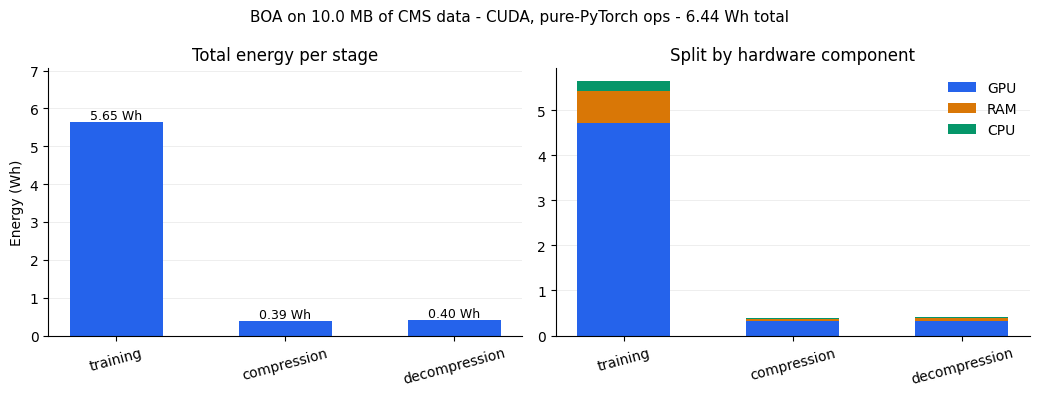

In [13]:
import matplotlib.pyplot as plt
import numpy as np

wh = lambda s, k: 0.0 if pd.isna(MEASUREMENTS[s][k]) else MEASUREMENTS[s][k] * 1000
totals = [MEASUREMENTS[s]["energy_kWh"] * 1000 for s in STAGES]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.0))

ax1.bar(STAGES, totals, color="#2563eb", width=0.55)
for x, v in enumerate(totals):
    ax1.annotate(f"{v:.2f} Wh", (x, v), ha="center", va="bottom", fontsize=9)
ax1.set_ylabel("Energy (Wh)")
ax1.set_title("Total energy per stage")
ax1.set_ylim(0, max(totals) * 1.25)

bottom = np.zeros(len(STAGES))
for label, key, colour in (("GPU", "gpu_kWh", "#2563eb"), ("RAM", "ram_kWh", "#d97706"),
                           ("CPU", "cpu_kWh", "#059669")):
    vals = np.array([wh(s, key) for s in STAGES])
    ax2.bar(STAGES, vals, bottom=bottom, label=label, color=colour, width=0.55)
    bottom += vals
ax2.set_title("Split by hardware component")
ax2.legend(frameon=False)

for ax in (ax1, ax2):
    ax.grid(axis="y", alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", rotation=15)

fig.suptitle(f"BOA on {len(data)/1e6:.1f} MB of CMS data - {DEVICE.upper()}, {BACKEND} - "
             f"{sum(totals):.2f} Wh total", fontsize=11)
fig.tight_layout()
plt.show()

<center><b>Figure 2.</b> Measured energy of the three BOA stages. Left: total per stage, showing the
one-off training cost against the per-file coding costs. Right: the same energy split by hardware
component - on a GPU runtime the GPU accounts for the large majority of every stage, while on a
CPU-only runtime the GPU segment is absent and only modelled CPU and RAM estimates remain.</center>

<a name="results-and-discussion"></a>

# Results & Discussion

### Reading `energy_kWh` and `emissions_kgCO2eq`

These two columns are not independent measurements — one is derived from the other:

* **`energy_kWh`** is the physical quantity. It is what CodeCarbon actually observed (partly by
  measurement, partly by modelling) and it is a property of *your job on your machine*. Move the
  same job to a different country and this number does not change.
* **`emissions_kgCO2eq`** is `energy_kWh` multiplied by the carbon intensity of the grid you told
  CodeCarbon you were on. It is a property of *your job, your machine and your location*.

So when you compare two models, two implementations or two codecs, **compare energy**. Reserve
emissions for the question "what did this actually cost the atmosphere, here?". Reporting only
emissions hides whether a difference came from better code or from a cleaner grid.

The per-component split also carries a message. Roughly 80% of the energy on a GPU run is the GPU
itself, which means efficiency work — smaller models, fewer epochs, mixed precision, early stopping —
pays off almost proportionally, whereas tuning your data loader does not.

### Three stages, three different lifetimes

The most important thing the three-row table tells you is not which number is biggest — it is that
the three numbers are paid on completely different schedules:

* **Training** is a one-off per dataset. It is usually the largest single figure, and it is also the
  one that shrinks fastest under ordinary engineering: fewer epochs, early stopping, a smaller model,
  or reusing one trained model across many files.
* **Compression** is paid once per file. If you compress a file once and it then sits in an archive,
  this cost is genuinely small.
* **Decompression** is paid **every single time somebody reads the data**. It is roughly as expensive
  as compression, because the model has to regenerate the same predictions to invert the coder.


A useful sanity check while reading your own table: compression and decompression should have
similar energies. If decompression is dramatically more expensive, that is the sequential, chunk-by-
chunk nature of decoding showing up — try more, smaller chunks so the GPU has more parallel streams.

### How much does the grid matter?

A great deal — often more than any code change you could make. The cell below takes the *same*
measured energy — the total across all three stages — and re-costs it against a range of grids,
using published annual-average intensities for 2024 [11, 12].

,gCO2eq_per_kWh,run_gCO2eq,vs_cleanest
Sweden,35,0.225267,1
France,41,0.263884,1.17143
United Kingdom,217,1.39665,6.2
Germany,330,2.12395,9.42857
United States,384,2.4715,10.9714
World average,473,3.04432,13.5143
India,670,4.31225,19.1429


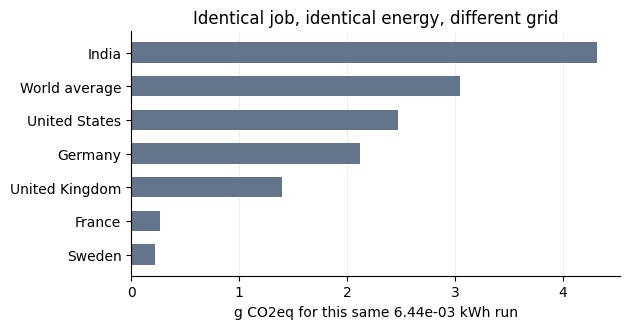

In [14]:
# Annual-average grid carbon intensity in g CO2eq per kWh, for 2024 - the most recent full year
# in the Ember data. Country figures via Our World in Data [11]; the world average is Ember's own
# global power-sector figure [12]. Rounded to whole numbers.
GRID_INTENSITY = {
    "Sweden":          35,
    "France":          41,
    "United Kingdom": 217,
    "Germany":        330,
    "United States":  384,
    "World average":  473,
    "India":          670,
}

energy_kWh = sum(MEASUREMENTS[s]["energy_kWh"] for s in STAGES)     # all measured stages
grid = (pd.DataFrame({"gCO2eq_per_kWh": GRID_INTENSITY})
          .assign(run_gCO2eq=lambda d: d["gCO2eq_per_kWh"] * energy_kWh)
          .sort_values("gCO2eq_per_kWh"))
grid["vs_cleanest"] = grid["run_gCO2eq"] / grid["run_gCO2eq"].min()
display(grid)

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.barh(grid.index, grid["run_gCO2eq"], color="#64748b", height=0.6)
ax.set_xlabel(f"g CO2eq for this same {energy_kWh:.2e} kWh run")
ax.set_title("Identical job, identical energy, different grid")
ax.grid(axis="x", alpha=0.25, lw=0.6)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

<center><b>Figure 3.</b> The same measured energy costed against different electricity grids. The
spread between the cleanest and dirtiest grid here is roughly 20x - larger than almost any
optimisation you could apply to the code itself.</center>

The practical lesson is that **where and when you run matters as much as what you run**. Moving a
long training job to a region with more hydro, wind or nuclear generation, or simply scheduling it
for a time of day when the grid is cleaner, can cut its footprint by more than a rewrite would.

One caveat worth internalising: the intensity CodeCarbon printed for your run may not match the
figures in the table above. CodeCarbon ships its own bundled dataset of grid intensities, and our
reference run on the UK grid was costed at 237.6 g CO<sub>2</sub>eq/kWh, against the 217 g
CO<sub>2</sub>eq/kWh the table above uses for the UK — close, but a different vintage of the same
kind of figure. The gap widens when the *boundary* changes rather than the year: for that same
2024, the UK system operator's own carbon intensity is 124 g CO<sub>2</sub>eq/kWh [13], because it
measures electricity supplied to the grid, counts imports at the generation mix of their country of
origin, and treats biomass on a lifecycle basis. None of the three is "wrong", and they differ by
nearly a factor of two. **Always state which intensity figure you used, and for which year.**

### What this measurement does *not* include

Being clear about the boundary is part of reporting honestly:

* **Embodied emissions** — manufacturing the T4, the server and the memory — are not counted at all.
  For short jobs on long-lived hardware the amortised share is small; for very short jobs on
  brand-new accelerators it is not negligible [10].
* **Data-centre overhead** is not included by default. Real facilities spend extra energy on cooling
  and power distribution, described by a multiplier called **PUE** (Power Usage Effectiveness): a
  PUE of 1.5 means 1.5 kWh drawn from the grid for every 1 kWh reaching the chips. CodeCarbon
  assumes no overhead unless you configure one, so a data-centre figure will be an underestimate.
* **Water** used for cooling is a separate footprint entirely, and not tracked here.
* **Idle and setup time** outside the `with` block — installing packages, downloading 50 MB of data,
  the machine sitting idle while you read this — cost real energy that no tracker in this notebook
  charged to anything.

### Sources of error

Short runs are noisy. Trackers have start-up cost, sampling is discrete (we sample once per second),
CPU and RAM figures are modelled from look-up tables rather than measured, and on a shared cloud VM
you cannot see what a co-tenant is doing to the physical machine. Treat a single small measurement
as an order-of-magnitude statement. If you need a number you can defend, run longer, run repeatedly,
and report a rate (kWh per epoch, per GB, per query) rather than a one-off total.

<a name="where-next"></a>

# Where to Go Next

You have measured a complete compress/decompress pipeline. The natural next steps, in increasing
order of effort:

**Experiment with this notebook.** Change `epochs` from 3 to 6 and confirm that training energy
roughly doubles while the compression ratio barely improves — the diminishing-returns curve that
makes early stopping an emissions decision. Change `country_iso` and watch the emissions move while
the energy stays put. Change `chunk_bytes` from 2048 to 512 and see what more parallel streams do to
decompression time on a GPU. Change `d_model` from 64 to 128 and see what a bigger model costs.

**Compare against a classical codec.** The measurement harness knows nothing about BOA: anything
that writes a compressed file and hands the bytes back fits inside the same two `track()` blocks.
Swapping in Python's built-in **LZMA** takes four lines, and putting its ratio and its energy beside
the numbers above is the comparison that decides whether a neural compressor is worth its
electricity.

**See the real experiment.** `01_run_BOA_and_CodeCarbon.ipynb` is the project's measurement notebook
proper. It runs the full 49.92 MB dataset with three separate CodeCarbon trackers and writes
machine-readable outputs (`results/boa_metrics.json`, per-stage CodeCarbon CSVs, the trained model
and the compressed artefact) that the project's later analysis notebooks consume. The reference
numbers quoted throughout this guide come from a run of that notebook on a Colab Tesla T4.

**Go deeper on the accounting.** The CCAI tutorial this notebook is modelled on [3] continues past
operational emissions into embodied-hardware estimation, water usage, and reporting via Model Cards
and Datasheets — the pieces of a complete footprint that we deliberately left out here.

<a name="references"></a>

# References

[1]\. Courty, B., Schmidt, V., Luccioni, S., Goyal-Kamal, Coutarel, M., et al. *CodeCarbon: Estimate
and track carbon emissions from machine learning computing*. Software repository, mlco2/codecarbon.
[https://github.com/mlco2/codecarbon](https://github.com/mlco2/codecarbon) — documentation at
[https://docs.codecarbon.io/](https://docs.codecarbon.io/)

[2]\. Kaack, L.H., Donti, P.L., Strubell, E., Kamiya, G., Creutzig, F., & Rolnick, D. (2022).
Aligning artificial intelligence with climate change mitigation. *Nature Climate Change*, 12,
518–527. [https://doi.org/10.1038/s41558-022-01377-7](https://doi.org/10.1038/s41558-022-01377-7)

[3]\. Hanna, M. & Perez Murcia, A.F. *Reducing Your Climate Impact When Training Machine Learning
Models* (Tracking Emissions from ML Models). Climate Change AI Tutorials.
[https://www.climatechange.ai/tutorials](https://www.climatechange.ai/tutorials) — notebook at
[https://github.com/climatechange-ai-tutorials/tracking-ml-emissions](https://github.com/climatechange-ai-tutorials/tracking-ml-emissions)

[4]\. Gupta, A. *BOA Constrictor: a Mamba-based lossless compressor for high energy physics data*.
Software repository.
[https://github.com/AkkiG2401/boa-constrictor](https://github.com/AkkiG2401/boa-constrictor)

[5]\. Gupta, A., Doglioni, C., & Elliott, T.J. (2026). BOA constrictor: a Mamba-based lossless
compressor for scientific data. *Machine Learning: Science and Technology*, 7, 035014.
[https://doi.org/10.1088/2632-2153/ae64a9](https://doi.org/10.1088/2632-2153/ae64a9)

[6]\. Gu, A. & Dao, T. (2023). Mamba: Linear-time sequence modeling with selective state spaces.
*arXiv preprint*. [https://arxiv.org/abs/2312.00752](https://arxiv.org/abs/2312.00752)

[7]\. Lannelongue, L., Grealey, J., & Inouye, M. (2021). Green algorithms: Quantifying the carbon
footprint of computation. *Advanced Science*, 8(12), 2100707.
[https://doi.org/10.1002/advs.202100707](https://doi.org/10.1002/advs.202100707)

[8]\. CERN Open Data Portal. CMS experiment open data.
[https://opendata.cern.ch/](https://opendata.cern.ch/)

[9]\. Bamler, R. (2022). Understanding entropy coding with asymmetric numeral systems (ANS): a
statistician's perspective. *arXiv preprint*.
[https://arxiv.org/abs/2201.01741](https://arxiv.org/abs/2201.01741)

[10]\. Luccioni, A.S., Viguier, S., & Ligozat, A.-L. (2023). Estimating the carbon footprint of
BLOOM, a 176B parameter language model. *Journal of Machine Learning Research*, 24(253), 1–15.
[https://jmlr.org/papers/v24/23-0069.html](https://jmlr.org/papers/v24/23-0069.html)

[11]\. Ritchie, H., Rosado, P., & Roser, M. Carbon intensity of electricity generation. *Our World in
Data*, based on Ember and the Energy Institute Statistical Review of World Energy. The country
figures used in this notebook are the 2024 values from this dataset.
[https://ourworldindata.org/grapher/carbon-intensity-electricity](https://ourworldindata.org/grapher/carbon-intensity-electricity)

[12]\. Ember (2025). *Global Electricity Review 2025*. Source of the world-average figure used here:
a global power-sector intensity of 473 g CO<sub>2</sub>eq/kWh in 2024, down from 484 in 2023.
[https://ember-energy.org/latest-insights/global-electricity-review-2025/](https://ember-energy.org/latest-insights/global-electricity-review-2025/)

[13]\. Evans, S. & Viisainen, V. (2025). Analysis: UK's electricity was cleanest ever in 2024.
*Carbon Brief*, using National Energy System Operator (NESO) carbon-intensity data.
[https://www.carbonbrief.org/analysis-uks-electricity-was-cleanest-ever-in-2024](https://www.carbonbrief.org/analysis-uks-electricity-was-cleanest-ever-in-2024)